# Importing all the essential Libraries

In [1]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
csv_path = "insurance.csv"
df = pd.read_csv(csv_path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

### Cleannig Dataset 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


###  Check Duplicate Rows

In [5]:
print("Total duplicate rows", df.duplicated().sum())

print(df[df.duplicated()])

Total duplicate rows 1
     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631


In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Problem statement - What kind of person usually costs the insurance company more?

### Initial Hypothesis :
1. Smokers usually pay much higher insurance charges.
2. Older people often have higher medical expenses.
3. Higher BMI may lead to health risks and increased costs.
4. People with more children may have slightly higher charges
5. Gender may not strongly affect charges

## **Univariate Analysis:**

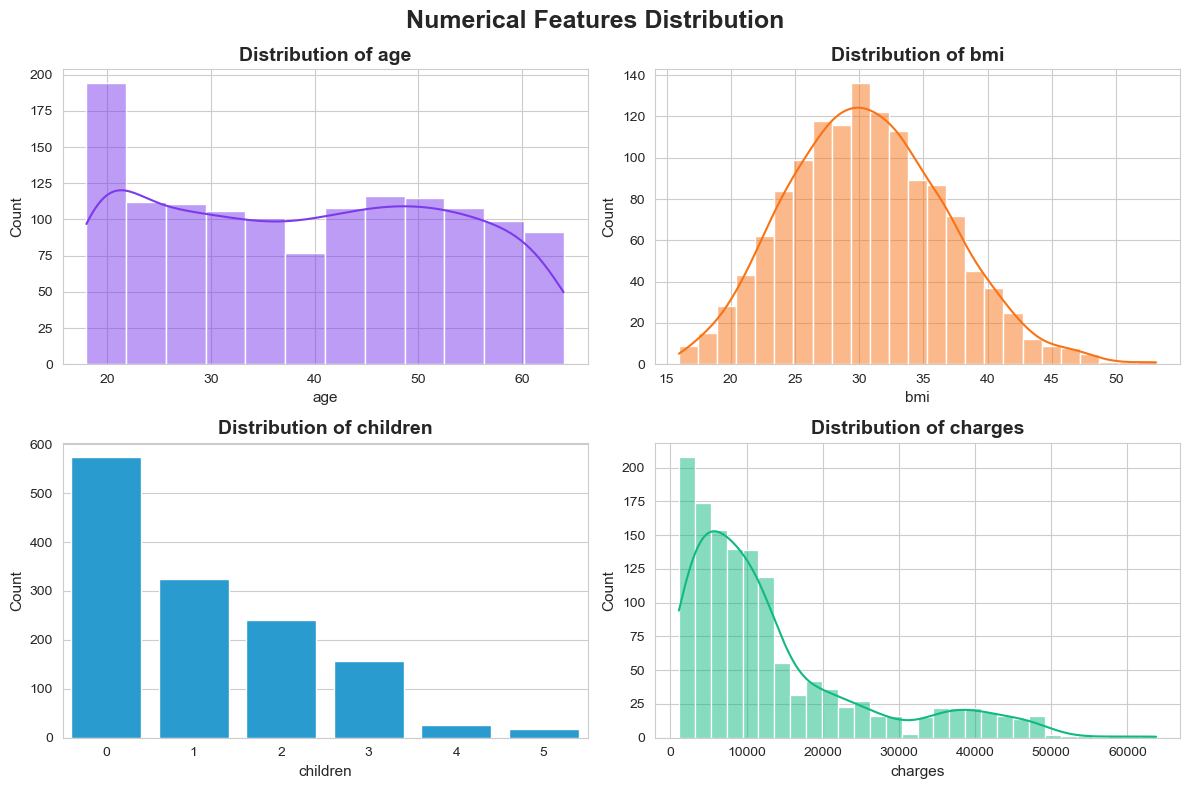

In [8]:
sns.set_style("whitegrid")
num_cols = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#7C3AED', '#F97316', '#0EA5E9', '#10B981']
for ax, col, color in zip(axes.flatten(), num_cols, colors):
    if col == 'children':
        sns.countplot(x=df[col], ax=ax, color=color)
    else:
        sns.histplot(df[col], kde=True, ax=ax, color=color)
    ax.set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
fig.suptitle("Numerical Features Distribution", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

- **AGE** Most people are between 18 to 60 years old, balanced across age groups, meaning both young and older adults are included,  insurance companies deal with customers from many age groups.
- **BMI** follows a bell-shaped curve. Most people have BMI around 25–35. many people are in: overweight category or close to obesity range. This is important because unhealthy BMI can increase medical risk.
- **Children** Most people have 0 or 1 childern , mainly represents smaller families
- **insurance charges** are highly unequal. A small group of individuals generates extremely high medical expenses.

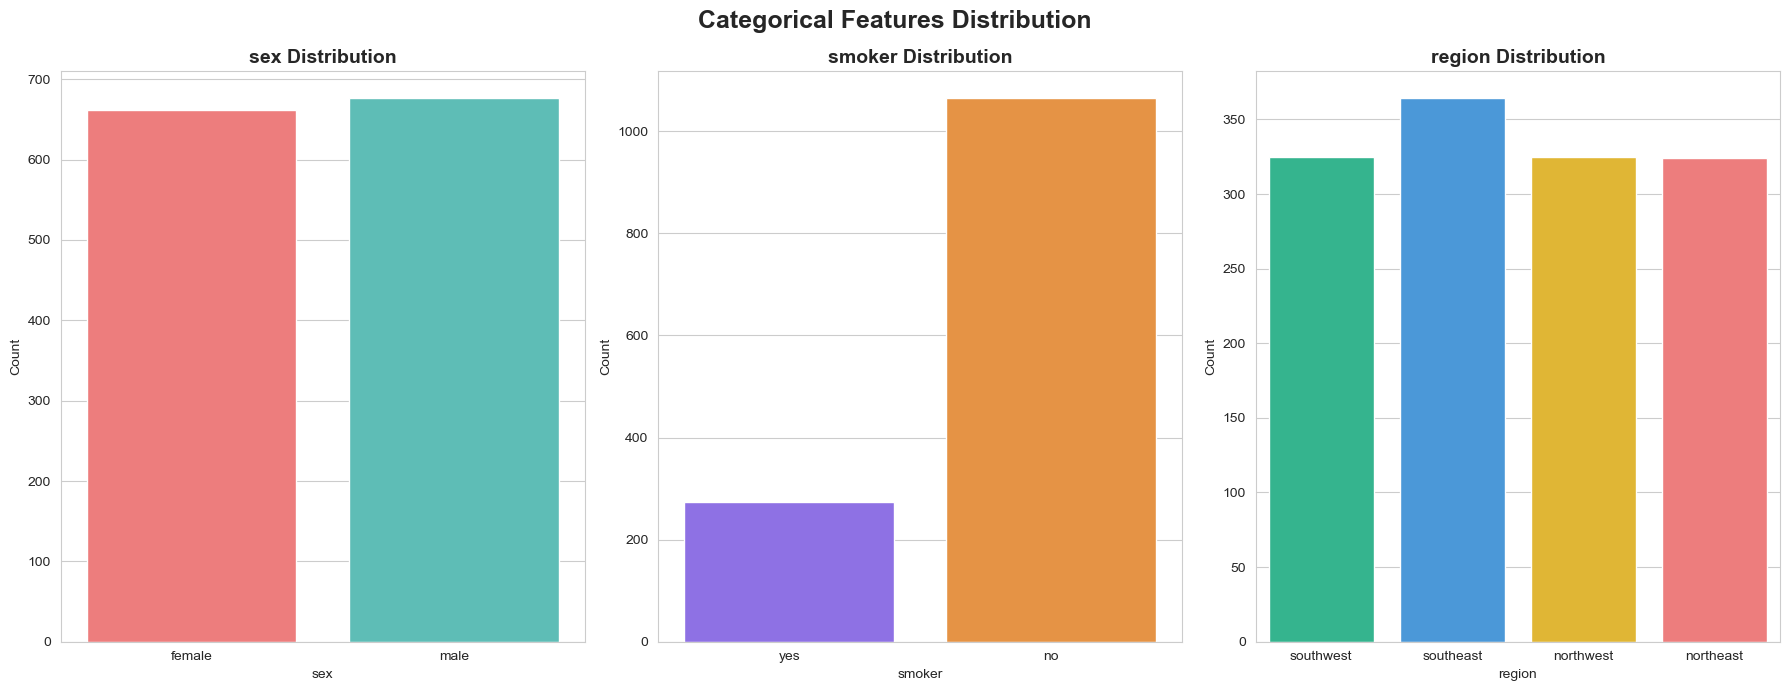

In [34]:
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
palette_list = [
    ['#FF6B6B', '#4ECDC4'],
    ['#845EF7', '#FF922B'],
    ['#20C997', '#339AF0', '#FCC419', '#FF6B6B']]
for ax, col, palette in zip(axes, cat_cols, palette_list):
    sns.countplot( x=df[col], hue=df[col], palette=palette, legend=False, ax=ax)
    ax.set_title(f'{col} Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
fig.suptitle("Categorical Features Distribution", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

- **Sex Distribution** : Male and female counts are almost equal.
- **Smoker Distribution** Most people are non-smokers, Only a smaller group are smokers, they may generate much larger insurance cost
- **Region Distribution** No region is dominating heavily, All regions have almost similar number of people.

###  1. Age vs Charges

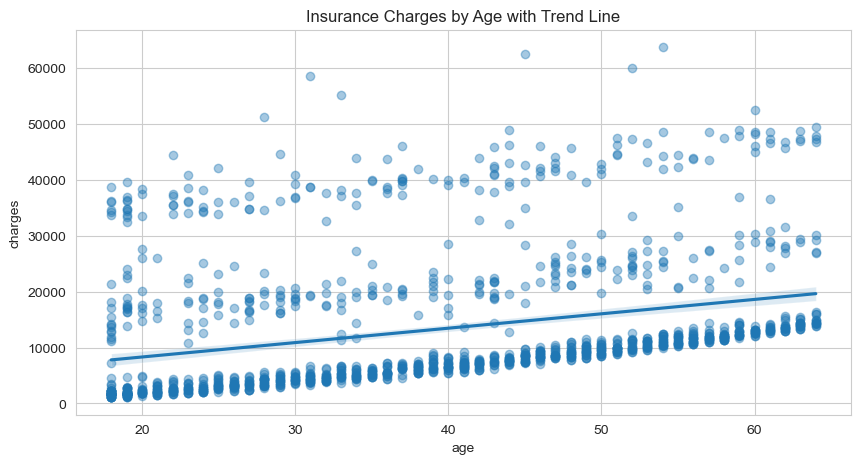

In [45]:
plt.figure(figsize=(10,5))
sns.regplot(data=df, x='age', y='charges', scatter_kws={'alpha':0.4})
plt.title('Insurance Charges by Age with Trend Line')
plt.show()

- The trend line is moving upward. As age increases, insurance charges generally increase too.
- but age alone does not explain all high-cost cases. Some older individuals still have low charges.

## 2. BMI vs Charges


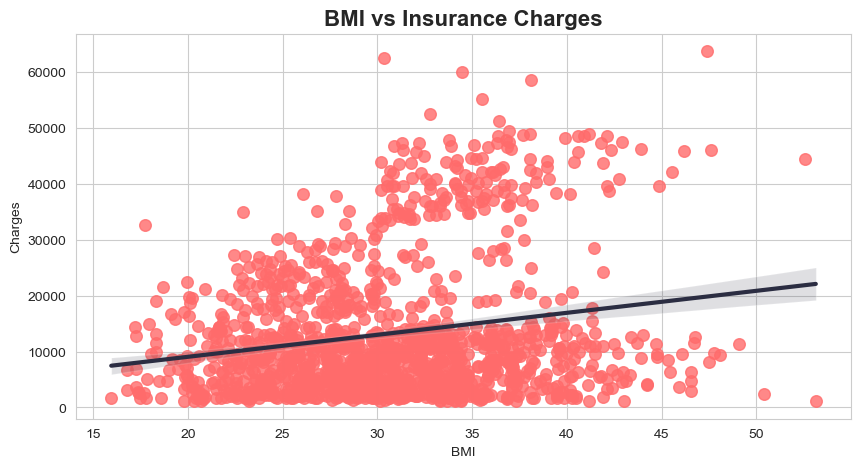

In [49]:
plt.figure(figsize=(10,5))
sns.regplot(x='bmi',y='charges',data=df,
    scatter_kws={'color':'#FF6B6B', 's':70},
    line_kws={'color':'#2B2D42', 'linewidth':3})
plt.title('BMI vs Insurance Charges', fontsize=16, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

- The upward trend line indicates: People with higher BMI tend to cost insurance companies more money.
- but not all high-BMI people have huge charges. Lifestyle behaviors like smoking likely intensify the financial impact.


## Smoker vs Insurance Charge

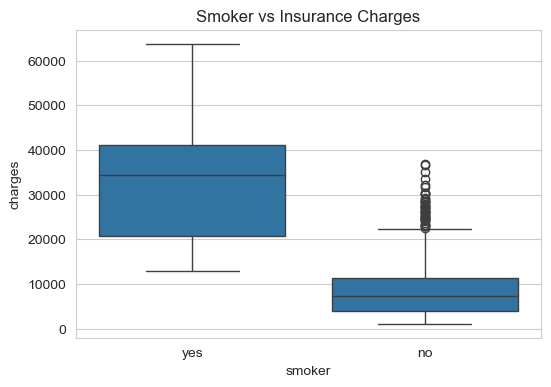

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Insurance Charges")
plt.show()

- Smokers clearly pay much higher insurance charges than non-smokers. Even the lowest smoker charges are higher than many non-smoker charges.
- Smokers are one of the biggest high-cost populations in the dataset.Helping customers quit smoking can reduce future insurance costs.
- This graph proves customers should not be treated equally. 
Insurance companies should create:low-risk, medium-risk, high-risk groups, based on health behavior.

### Charges by Sex:

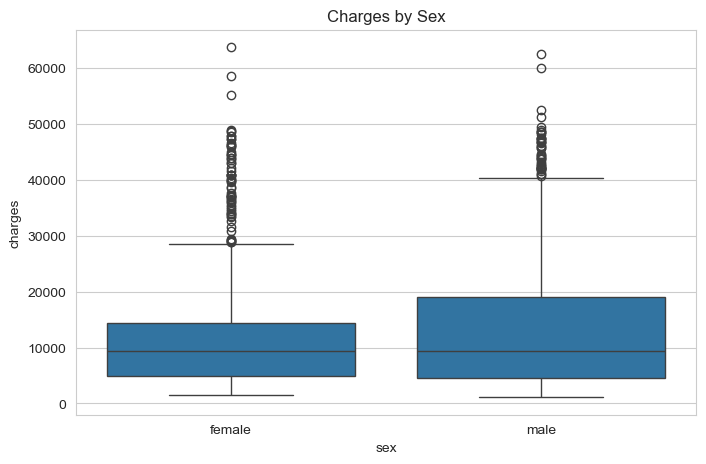

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sex', y='charges')
plt.title('Charges by Sex')
plt.show()

- Both groups looks similar, that means - Gender alone does not create a huge difference in insurance charges.
- This graph suggests that: 
healthcare expenses are influenced more by lifestyle and health conditions , than biological gender alone.

### Charges by Region:

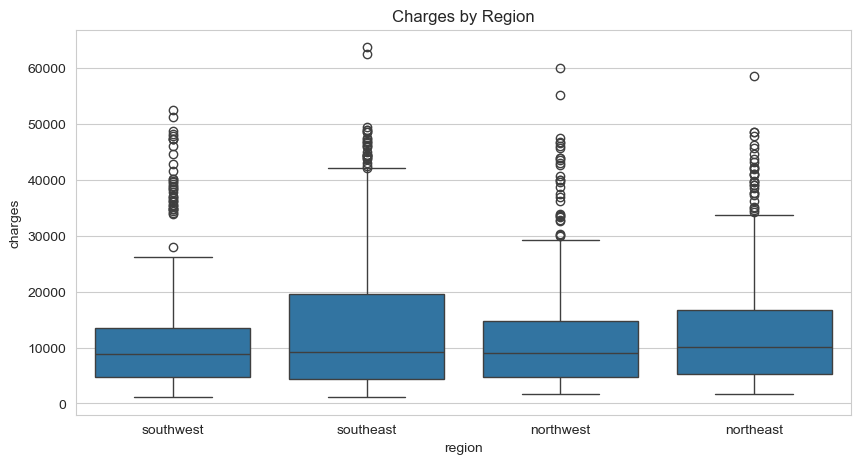

In [51]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='region', y='charges')
plt.title('Charges by Region')
plt.show()

- all regions look somewhat similar, But southeast region stands out slightly: wider distribution , more expensive outlier, higher upper range.
- people in the southeast region may generate slightly higher insurance costs.
- regional lifestyle patterns may be influencing health outcomes.

## **Multivariate Analysis :**

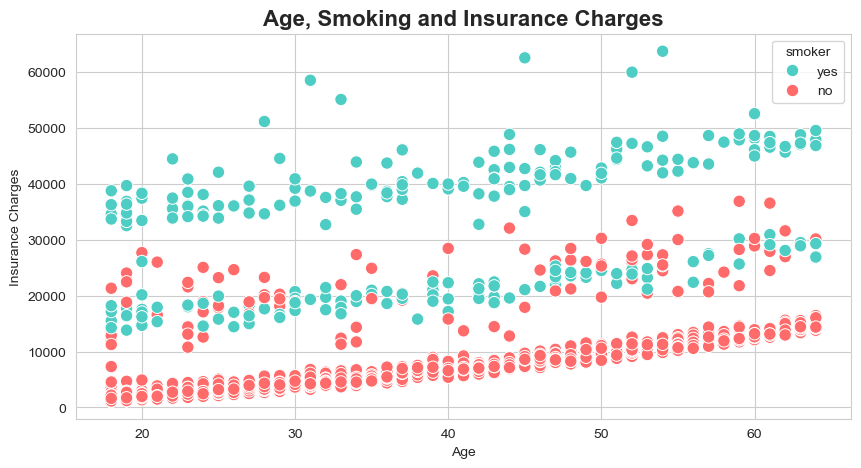

In [19]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='age',y='charges',hue='smoker',data=df,palette=['#4ECDC4', '#FF6B6B'],s=80)
plt.title('Age, Smoking and Insurance Charges', fontsize=16, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.show()

- Most non-smokers: stay in lower charge ranges, show gradual increase with age, have relatively controlled insurance costs.
- Even older non-smokers mostly remain below very extreme charge levels.
- Smokers form a completely separate high-cost cluster.
- Smoking dramatically increases insurance charges across all ages, and older smokers emerge as one of the most financially risky customer groups.

### Smoking & BMI VS Charges :

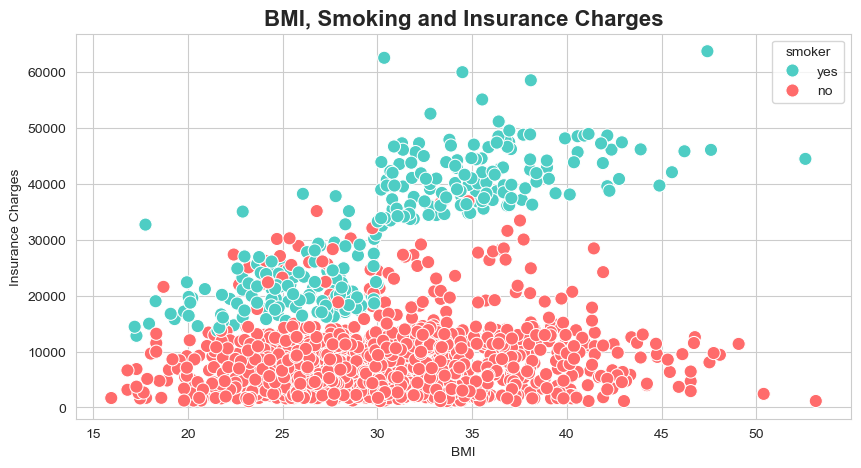

In [16]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='bmi',y='charges',hue='smoker',data=df,palette=['#4ECDC4', '#FF6B6B'],s=90)
plt.title('BMI, Smoking and Insurance Charges', fontsize=16, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.show()

- Smokers with high BMI generate the highest insurance charges in the dataset.
- Many smokers with BMI above 30 have extremely high charges.
- Not all high-BMI individuals have high charges. *Obesity alone is not enough to create extreme medical costs.*

### Correlation heatmap


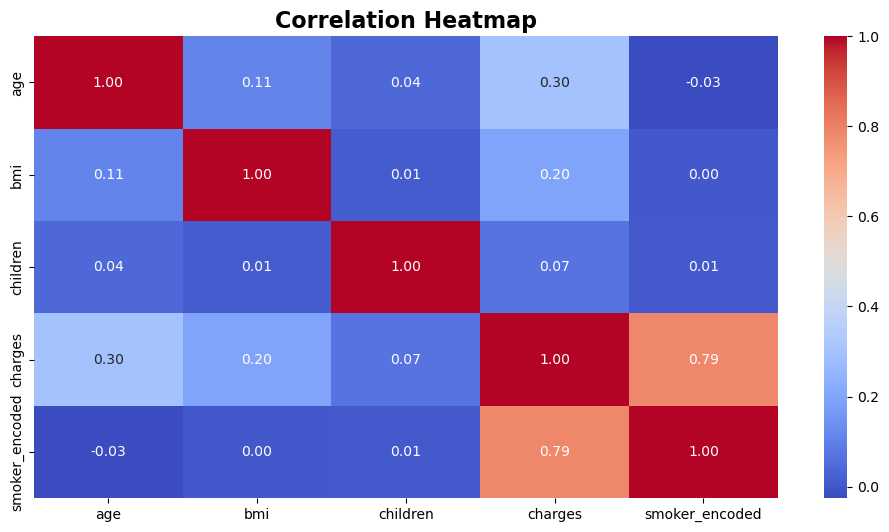

In [10]:
df['smoker_encoded'] = df['smoker'].map({'yes':1, 'no':0})
plt.figure(figsize=(12,6))
sns.heatmap(
    df[['age','bmi','children','charges','smoker_encoded']].corr(),
    annot=True,cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')

plt.show()

- Smoking has the strongest relationship with insurance charges by a HUGE margin. 
Its correlation is: 0.79
- Age has moderate positive correlation: 0.30 , charges generally increase with age
- BMI shows smaller positive correlation: 0.20 , effect is weaker than smoking, Still important though.
- Children has almost NO correlation: 0.07,Having more children does not automatically increase medical insurance costs.

# Executive Summary: Insurance Risk EDA

## 1. The Core Story
The insured population is generally stable, with most customers generating moderate costs. However, a small, high-risk segment drives disproportionately high claims. Financial exposure is primarily dictated by modifiable lifestyle behaviors rather than fixed demographic traits.

## 2. Key Findings & Risk Patterns
* **The Dominant Drivers:** Smoking status is the absolute strongest predictor of high charges, followed closely by age and BMI. 
* **The Low-Impact Factors:** Gender, geographic region, and the number of dependents (children) show minimal to weak correlations with insurance costs.
* **Risk Co-morbidities:** Risk amplifies exponentially when factors combine. The highest financial risk concentration exists within the **older smoker with high BMI** cohort, while the lowest risk sits with **younger, healthy-BMI non-smokers**.

## 3. Actionable Business Decisions

### Premium Pricing & Underwriting
* Implement aggressive, compounded risk-based pricing tiers explicitly targeting the intersection of smoking status and elevated BMI.
* Tighten underwriting guidelines for older applicants exhibiting multiple lifestyle risk factors.

### Wellness & Preventative Programs
* Launch incentivized smoking cessation and targeted weight-management programs to directly lower the cost of active, high-risk claims.
* Focus preventative healthcare marketing on middle-aged policyholders to mitigate chronic, high-cost health escalations.

### Marketing & Customer Acquisition
* Shift acquisition budgets to target younger, non-smoking, and wellness-oriented demographics to maximize long-term portfolio profitability.